# Jupyter notebook for getting compute times from output files for the size effect simulations

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import json

here below

In [ ]:
def hms_to_seconds(hms):
    h, m, s = map(int, hms.split(":"))
    return h * 3600 + m * 60 + s

def parse_lammps_runs_to_dict(text):
    created_atoms_re = re.compile(r"Created\s+(\d+)\s+atoms")
    cpu_re = re.compile(
        r"CPU use with\s+(\d+)\s+MPI tasks\s+x\s+(\d+)\s+OpenMP threads"
    )
    loop_re = re.compile(
        r"Loop time of\s+[0-9.eE+-]+\s+on\s+(\d+)\s+procs\s+for\s+\d+\s+steps\s+with\s+(\d+)\s+atoms"
    )
    wall_re = re.compile(r"Total wall time:\s*([0-9]+:[0-9]{2}:[0-9]{2})")

    runs_by_atoms = {}
    current_atoms = None
    current_cpus = None

    for line in text.splitlines():
        line = line.strip()

        m_atoms = created_atoms_re.search(line)
        if m_atoms:
            current_atoms = int(m_atoms.group(1))
            current_cpus = None
            continue

        m_cpu = cpu_re.search(line)
        if m_cpu:
            current_cpus = int(m_cpu.group(1)) * int(m_cpu.group(2))
            continue

        m_loop = loop_re.search(line)
        if m_loop and current_cpus is None:
            current_cpus = int(m_loop.group(1))
            if current_atoms is None:
                current_atoms = int(m_loop.group(2))
            continue

        m_wall = wall_re.search(line)
        if m_wall and current_atoms is not None:
            if current_atoms not in runs_by_atoms:
                runs_by_atoms[current_atoms] = {
                    "total_wall_time_s": [],
                    "n_cpus": []
                }

            runs_by_atoms[current_atoms]["total_wall_time_s"].append(
                hms_to_seconds(m_wall.group(1))
            )
            runs_by_atoms[current_atoms]["n_cpus"].append(current_cpus)

    return runs_by_atoms

def merge_runs_dicts(dict_list):
    merged = {}

    for d in dict_list:
        for n_atoms, vals in d.items():
            if n_atoms not in merged:
                merged[n_atoms] = {
                    "total_wall_time_s": [],
                    "n_cpus": []
                }

            merged[n_atoms]["total_wall_time_s"].extend(vals["total_wall_time_s"])
            merged[n_atoms]["n_cpus"].extend(vals["n_cpus"])

    return merged

# --- your paths ---
base = '/home/groups/earlew/arlenlex/P1-model-dev/simple_shear/size_effect/out_files_smno'
paths = [
    os.path.join(base, 'size_effect_tests_22983281.out'),
]

# --- parse all files ---
all_runs_dicts = []

for log_path in paths:
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    all_runs_dicts.append(parse_lammps_runs_to_dict(text))

# --- merge into one dictionary ---
runs_dict = merge_runs_dicts(all_runs_dicts)

Performance summary:
     873 atoms |  10 runs | mean wall time =     2.00 s | mean CPU-hours = 0.0006
    1257 atoms |  10 runs | mean wall time =     3.00 s | mean CPU-hours = 0.0008
    2237 atoms |  10 runs | mean wall time =     6.00 s | mean CPU-hours = 0.0017
    3496 atoms |  10 runs | mean wall time =     5.30 s | mean CPU-hours = 0.0029
   13987 atoms |  10 runs | mean wall time =    46.70 s | mean CPU-hours = 0.0259
   31475 atoms |  10 runs | mean wall time =   117.40 s | mean CPU-hours = 0.1304
   55954 atoms |  10 runs | mean wall time =   219.60 s | mean CPU-hours = 0.2440
   87431 atoms |  10 runs | mean wall time =   153.30 s | mean CPU-hours = 0.3832
  125900 atoms |  10 runs | mean wall time =   425.10 s | mean CPU-hours = 1.0628
  171366 atoms |  10 runs | mean wall time =   614.20 s | mean CPU-hours = 1.5355
  223824 atoms |  10 runs | mean wall time =   836.20 s | mean CPU-hours = 2.0905
  283279 atoms |  10 runs | mean wall time =  1104.40 s | mean CPU-hours = 2.

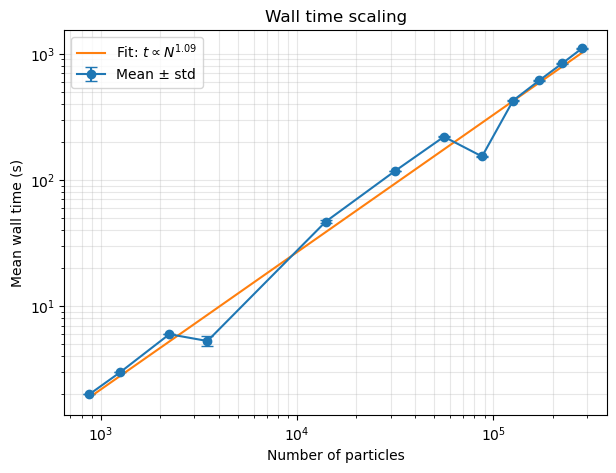

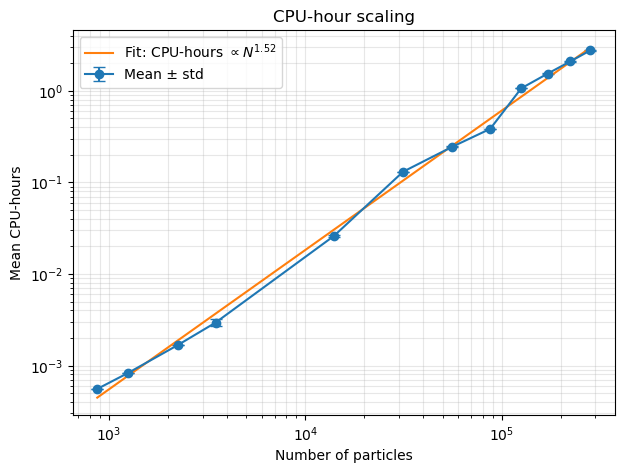

In [ ]:
# --- summarize by atom count ---
atom_counts = np.array(sorted(runs_dict.keys()), dtype=float)

mean_wall_time_s = np.array([
    np.mean(runs_dict[n]["total_wall_time_s"]) for n in atom_counts
])
std_wall_time_s = np.array([
    np.std(runs_dict[n]["total_wall_time_s"]) for n in atom_counts
])

mean_cpu_hours = np.array([
    np.mean(np.array(runs_dict[n]["total_wall_time_s"]) * np.array(runs_dict[n]["n_cpus"]) / 3600.0)
    for n in atom_counts
])
std_cpu_hours = np.array([
    np.std(np.array(runs_dict[n]["total_wall_time_s"]) * np.array(runs_dict[n]["n_cpus"]) / 3600.0)
    for n in atom_counts
])

n_runs = np.array([len(runs_dict[n]["total_wall_time_s"]) for n in atom_counts], dtype=int)

# --- power-law fit: y = a * N^alpha ---
# log(y) = log(a) + alpha * log(N)
def fit_power_law(x, y):
    logx = np.log(x)
    logy = np.log(y)
    alpha, loga = np.polyfit(logx, logy, 1)
    a = np.exp(loga)

    y_fit = a * x**alpha

    # R^2 in log-log space
    ss_res = np.sum((logy - np.log(y_fit))**2)
    ss_tot = np.sum((logy - np.mean(logy))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return a, alpha, y_fit, r2

a_wall, alpha_wall, wall_fit, r2_wall = fit_power_law(atom_counts, mean_wall_time_s)
a_cpu, alpha_cpu, cpu_fit, r2_cpu = fit_power_law(atom_counts, mean_cpu_hours)

# --- print summary ---
print("Performance summary:")
for n, nr, wt, cpuh in zip(atom_counts.astype(int), n_runs, mean_wall_time_s, mean_cpu_hours):
    print(f"{n:>8} atoms | {nr:>3} runs | mean wall time = {wt:8.2f} s | mean CPU-hours = {cpuh:.4f}")

print("\nPower-law fits:")
print(f"Wall time:   t(N) = {a_wall:.3e} * N^{alpha_wall:.3f}    (R^2 in log-log space = {r2_wall:.4f})")
print(f"CPU-hours:   c(N) = {a_cpu:.3e} * N^{alpha_cpu:.3f}    (R^2 in log-log space = {r2_cpu:.4f})")

# --- plot wall time scaling ---
plt.figure(figsize=(7, 5))
plt.errorbar(atom_counts, mean_wall_time_s, yerr=std_wall_time_s, marker='o', capsize=4, label="Mean ± std")
plt.plot(atom_counts, wall_fit, label=fr"Fit: $t \propto N^{{{alpha_wall:.2f}}}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of particles")
plt.ylabel("Mean wall time (s)")
plt.title("Wall time scaling")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

# --- plot CPU-hour scaling ---
plt.figure(figsize=(7, 5))
plt.errorbar(atom_counts, mean_cpu_hours, yerr=std_cpu_hours, marker='o', capsize=4, label="Mean ± std")
plt.plot(atom_counts, cpu_fit, label=fr"Fit: CPU-hours $\propto N^{{{alpha_cpu:.2f}}}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of particles")
plt.ylabel("Mean CPU-hours")
plt.title("CPU-hour scaling")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [5]:
out_dir = "/scratch/groups/earlew/arlenlex/P1-model-dev/simple_shear/size_effect/ensemble10_smno"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "runs_dict.json")

# json needs plain Python ints, not numpy ints
runs_dict_clean = {
    int(n_atoms): {
        "total_wall_time_s": [int(x) for x in vals["total_wall_time_s"]],
        "n_cpus": [int(x) for x in vals["n_cpus"]],
    }
    for n_atoms, vals in runs_dict.items()
}

with open(out_path, "w") as f:
    json.dump(runs_dict_clean, f, indent=2)

print(f"Saved to: {out_path}")

Saved to: /scratch/groups/earlew/arlenlex/P1-model-dev/simple_shear/size_effect/ensemble10_smno/runs_dict.json
